In [17]:
import numpy as np
import math
from scipy.stats import linregress
from scipy.linalg import eigvalsh
import matplotlib.pyplot as plt

# Basic Functions

In [11]:
#kronecker product code for more than 2 inputs
def kron(*matrices):
    result = np.array([[1]])
    for matrix in matrices:
        result = np.kron(result, matrix)
    return result

#Partial Trace Code
def IntegerDigits(n, b, l):
    digits = [0] * l
    pos = l - 1
    while pos != -1:
        digits[pos] = int(n % b)
        n //= b
        pos -= 1
    return digits

def FromDigits(digits, base):
    digits = digits[::-1]
    n = 0
    for i, d in enumerate(digits):
        n += d * base**i
        
    return n

def SwapParts(digits, p1, p2):
    new = np.copy(digits)
    new[p1] = digits[p2]
    new[p2] = digits[p1]
    return new

def dTraceSystem(D,s,dimen):
    Qudits=sorted(s)
    Qudits.reverse()
    TrkM = D
    z=len(Qudits)
    
    for q in range(z):
        n=math.log(TrkM.shape[0],dimen)
        assert n % 1 == 0
        n = int(n)
        
        M=TrkM
        M = np.array(M , dtype = complex)
        k=Qudits[q]
        temp = np.zeros(M.shape[0], dtype=complex)
        if k!=n:
            for j in range(n-k):
                b={0}
                for i in range(dimen**n):
                    digits=IntegerDigits(i,dimen,n)
                    if digits[n-1] != digits[n-j-2] and i not in  b:
                        number=FromDigits(
                            SwapParts(digits, n-1, n-j-2),
                            dimen
                        )
                        b.add(number)

                        temp[:] = M[i, :]
                        M[i, :] = M[number, :]
                        M[number, :] = temp

                        temp[:] = M[:, i]
                        M[:, i] = M[:, number]
                        M[:, number] = temp
        
        TrkM=[]
        for p in range(0,dimen**n,dimen):
            TrkM.append(
                sum(
                    M[p+h, h:dimen**n:dimen]
                    for h in range(dimen)
                )
            )
        TrkM = np.array(TrkM)
    
    return TrkM
#Recall matrix as dTraceSystem(matrix,[systems I want to trace out],dimension of system)

#defining basis vectors

#zero vector and its conjugate transpose                                         
zero= np.array([[1],[0]])
zeroCT=np.conjugate(zero.T)
#one vector and its conjugate transpose
one=np.array([[0],[1]])
oneCT=np.conjugate(one.T)
#plus vector and its conjugate transpose
plus=np.array([[1],[1]])*1/math.sqrt(2)
plusCT=np.conjugate(plus.T)
#minus vector and its conjugate transpose
minus=np.array([[1],[-1]])*1/math.sqrt(2)
minusCT=np.conjugate(minus.T)
#plusy and its conjugate transpose
plusy=np.array([[1],[complex(0.0, 1)]])*1/math.sqrt(2)
plusyCT=np.conjugate(plusy.T)
#minusy and its conjugate transpose
minusy=np.array([[1],[complex(0.0, -1)]])*1/math.sqrt(2)
minusyCT=np.conjugate(minusy.T)
#defining the Bell states
phiplus=(np.kron(zero, zero)+np.kron(one, one))*1/math.sqrt(2)
phiminus=(np.kron(zero, zero)-np.kron(one, one))*1/math.sqrt(2)
psiplus=(np.kron(zero, one)+np.kron(one, zero))*1/math.sqrt(2)
psiminus=(np.kron(zero, one)-np.kron(one, zero))*1/math.sqrt(2)
#defining the outer product of the Bell states
Phiplus=phiplus@np.conjugate(phiplus.T)
Phiminus=phiminus@np.conjugate(phiminus.T)
Psiplus=psiplus@np.conjugate(psiplus.T)
Psiminus=psiminus@np.conjugate(psiminus.T)
#defining Pauli matrices
pauliX=np.array([[0,1],[1,0]])
pauliY=np.array([[0,complex(0,-1)],[complex(0,1),0]])
pauliZ=np.array([[1,0],[0,-1]])

In [6]:
# ----------------------------
# Parameters
# ----------------------------
Ls = np.arange(0, 150, 1.0)
Nreg_values = [1, 2, 3, 4, 5, 6, 7, 8, 9]
m_values = np.arange(1, 21)
n_vals = [1, 2, 4, 8, 16]
n_scan_vals = np.arange(1, 17)

M = 1
q = 0.7
tau = 1e-8

# Importing HR files

In [2]:
import numpy as np

results_5dB = np.load(
    "gkp_raw_results_5dB_Nreg1_to_6.npy",
    allow_pickle=True
).item()

results_10dB = np.load(
    "gkp_raw_results_10dB_Nreg1_to_6.npy",
    allow_pickle=True
).item()

results_20dB = np.load(
    "gkp_raw_results_20dB_Nreg1_to_6.npy",
    allow_pickle=True
).item()

In [3]:
results_by_squeezing = {
    5: results_5dB,
    10: results_10dB,
    20: results_20dB,
}

In [4]:
for squeezing_dB, results in results_by_squeezing.items():

    print(f"\nSqueezing = {squeezing_dB} dB")

    for Nreg in sorted(results.keys()):
        print(
            f"  Nreg = {Nreg}, "
            f"available m = {sorted(results[Nreg].keys())}"
        )


Squeezing = 5 dB
  Nreg = 1, available m = [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
  Nreg = 2, available m = [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
  Nreg = 3, available m = [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
  Nreg = 4, available m = [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(

In [7]:
# ============================================================
# Global GKP hashing-rate envelope for each squeezing level
# ============================================================

global_gkp_envelopes = {}

for squeezing_dB, results in results_by_squeezing.items():

    print(f"\nComputing global GKP envelope for {squeezing_dB} dB")

    Nreg_envelopes = {}

    # --------------------------------------------------------
    # Maximise over n and m for each Nreg
    # --------------------------------------------------------

    for Nreg in sorted(results.keys()):

        available_m = sorted(results[Nreg].keys())

        m_envelopes = []

        for m in available_m:

            out = results[Nreg][m]

            # Stack all fixed-n curves
            fixed_n_curves = np.vstack([
                np.asarray(
                    out["fixed_n_data"][n]["rate"],
                    dtype=float
                )
                for n in n_vals
            ])

            # Maximum over repeater number n
            max_over_n = np.max(
                fixed_n_curves,
                axis=0
            )

            m_envelopes.append(max_over_n)

        # Maximum over temporal multiplexing m
        max_over_m = np.max(
            np.vstack(m_envelopes),
            axis=0
        )

        Nreg_envelopes[Nreg] = max_over_m

    # --------------------------------------------------------
    # Maximum over Nreg
    # --------------------------------------------------------

    Nreg_stack = np.vstack([
        Nreg_envelopes[Nreg]
        for Nreg in sorted(Nreg_envelopes.keys())
    ])

    global_gkp_envelopes[squeezing_dB] = np.max(
        Nreg_stack,
        axis=0
    )

print("\nDone.")


Computing global GKP envelope for 5 dB

Computing global GKP envelope for 10 dB

Computing global GKP envelope for 20 dB

Done.


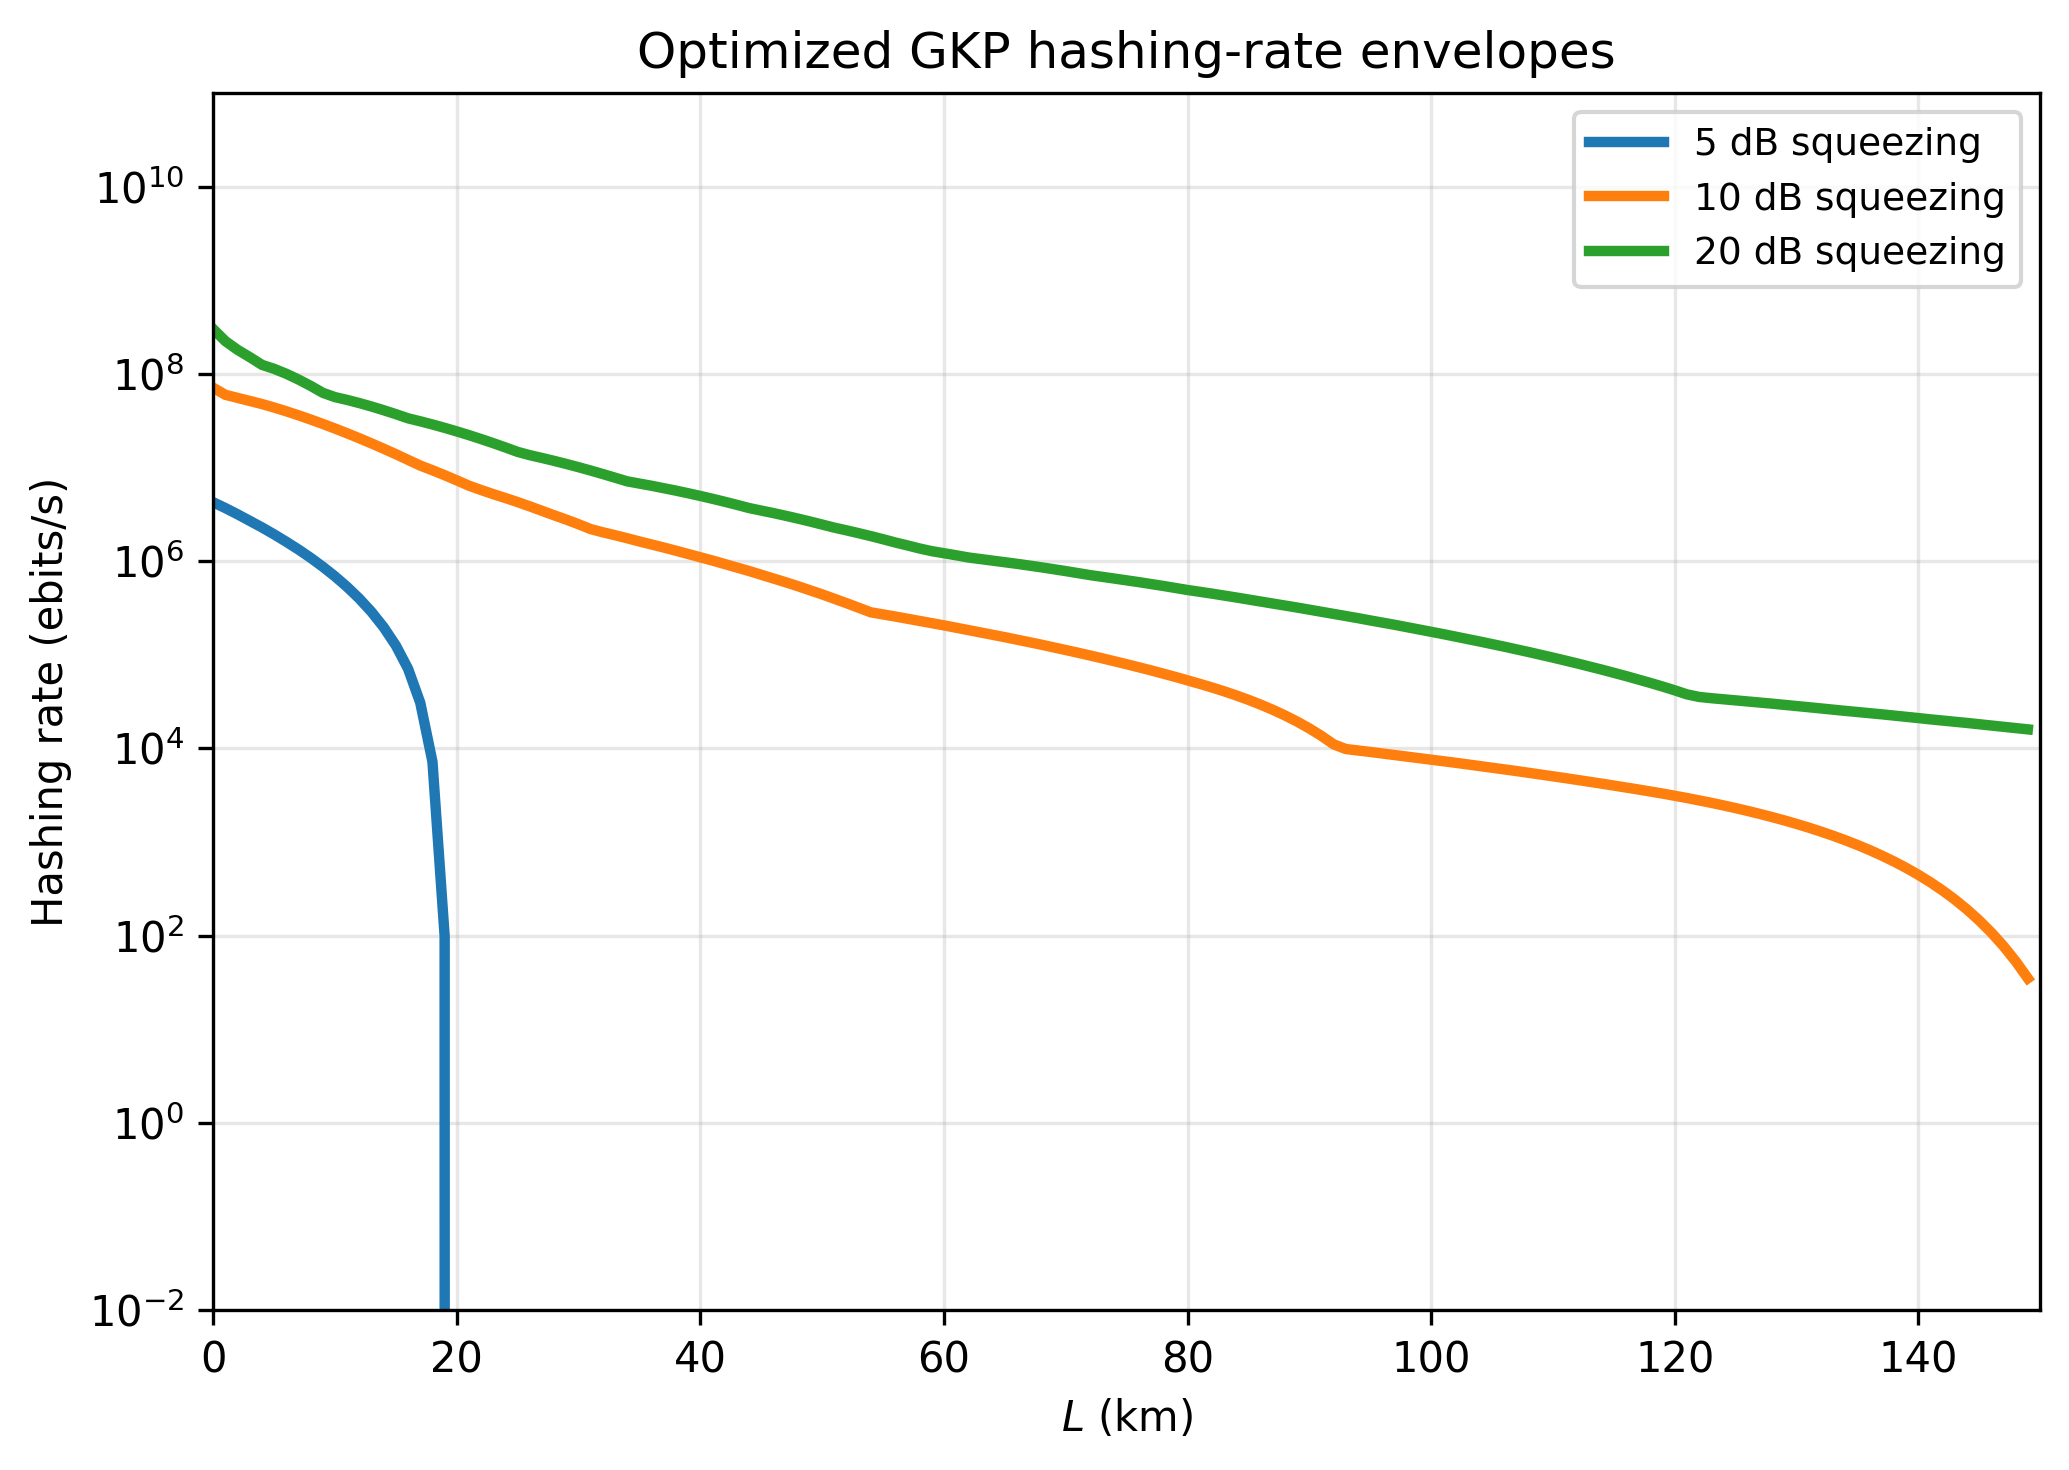

In [29]:
# ============================================================
# Plot globally optimised GKP envelopes
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5),
    dpi=300
)

for squeezing_dB in [5, 10, 20]:

    ax.plot(
        Ls,
        global_gkp_envelopes[squeezing_dB],
        linewidth=2.5,
        label=f"{squeezing_dB} dB squeezing"
    )

ax.set_yscale("log")

ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate (ebits/s)")

ax.set_title(
    "Optimized GKP hashing-rate envelopes"
)

ax.set_xlim(0, 150)
ax.set_ylim(1e-2, 1e11)

ax.grid(
    True,
    which="both",
    alpha=0.3
)

ax.legend(fontsize=9)

plt.tight_layout()

plt.show()

# PLOB

/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_21297/1776416397.py:9: RuntimeWarning: divide by zero encountered in log2
  return -np.log2(1 - eta) * (M / tau)


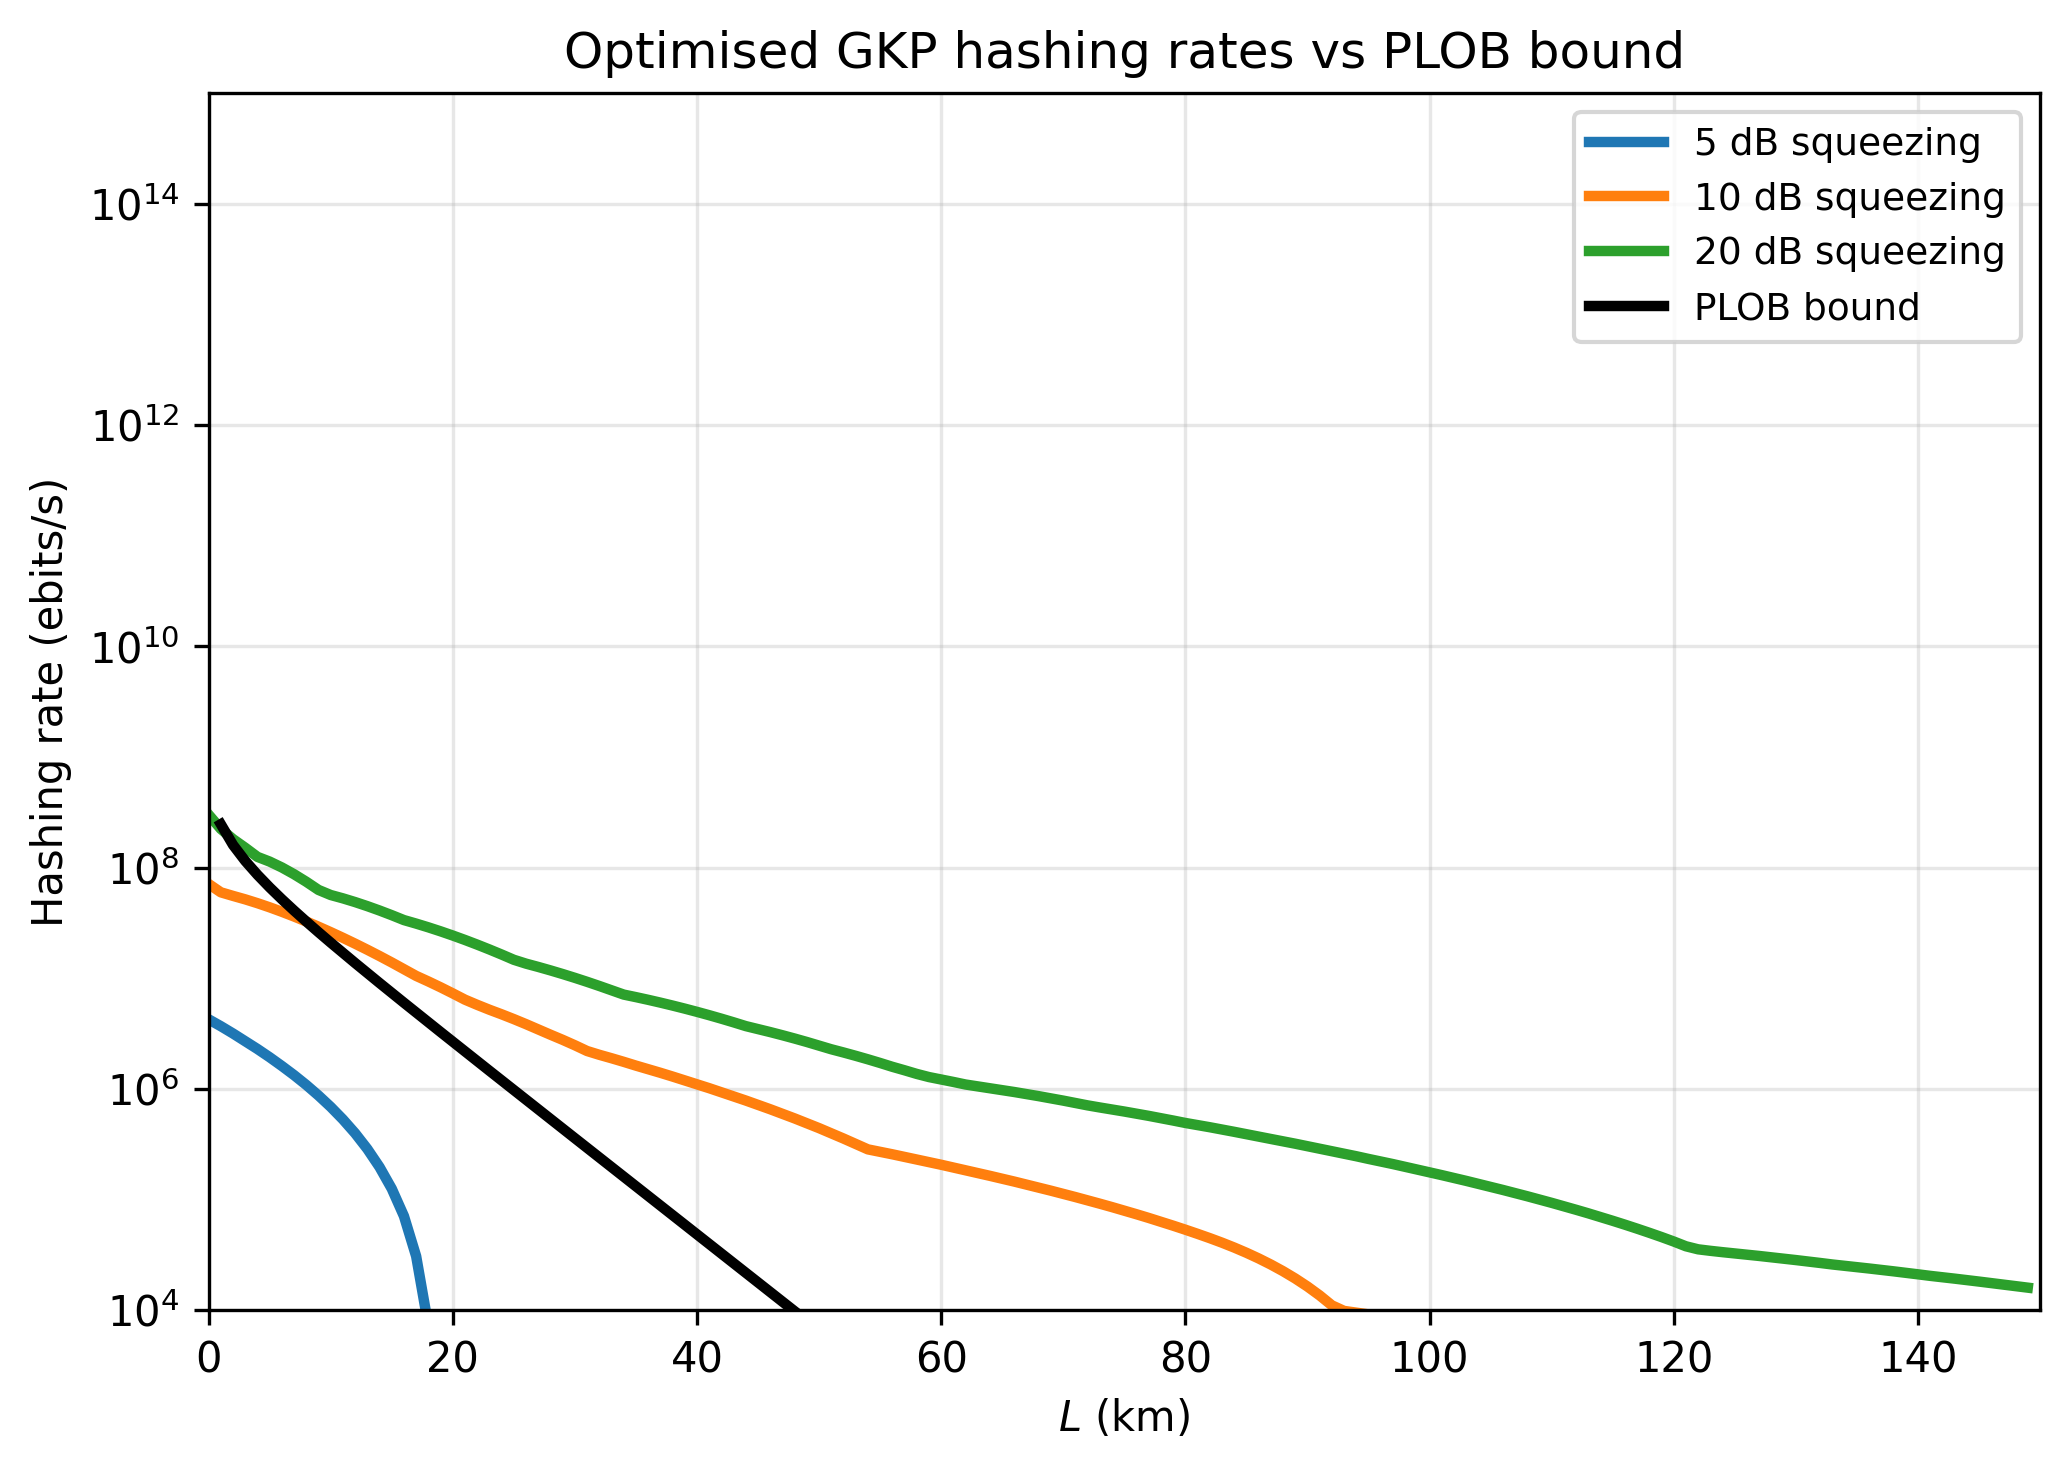

In [16]:
# ============================================================
# PLOB bound
# ============================================================

def PLOB_bound(L, alpha_dB_per_km=0.2, M=1, tau=1e-8):

    eta = np.exp(-alpha_dB_per_km * L)

    return -np.log2(1 - eta) * (M / tau)


# ============================================================
# L grid
# ============================================================

Ls = np.arange(0, 150, 1.0)

PLOB_bound_tab = PLOB_bound(
    Ls,
    alpha_dB_per_km=0.2,
    M=M,
    tau=tau
)


# ============================================================
# Plot maximised GKP envelopes + PLOB
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5),
    dpi=300
)


# ------------------------------------------------------------
# Plot globally maximised GKP envelope for each squeezing
# ------------------------------------------------------------

for squeezing_dB in [5, 10, 20]:

    ax.plot(
        Ls,
        global_gkp_envelopes[squeezing_dB],
        linewidth=2.5,
        label=f"{squeezing_dB} dB squeezing"
    )


# ------------------------------------------------------------
# Plot PLOB bound
# ------------------------------------------------------------

ax.plot(
    Ls,
    PLOB_bound_tab,
    color="black",
    linestyle="-",
    linewidth=2.5,
    label="PLOB bound"
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_yscale("log")

ax.set_ylim(
    bottom=1e4,
    top=1e15
)

ax.set_xlim(
    left=0,
    right=150
)

ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate (ebits/s)")

ax.set_title(
    "Optimised GKP hashing rates vs PLOB bound"
)

ax.grid(
    True,
    which="both",
    alpha=0.3
)

ax.legend(
    fontsize=9
)

plt.tight_layout()

plt.show()
plt.close(fig)

# Dual-Rail

In [18]:
def r(p, q):
    return np.array([
        p[3]*q[0] + p[2]*q[1] + p[1]*q[2] + p[0]*q[3],
        p[2]*q[0] + p[3]*q[1] + p[0]*q[2] + p[1]*q[3],
        p[1]*q[0] + p[0]*q[1] + p[3]*q[2] + p[2]*q[3],
        p[0]*q[0] + p[1]*q[1] + p[2]*q[2] + p[3]*q[3]
    ])

def rNtimes(p, n):
    if n == 1:
        return r(p, p)
    else:
        return r(rNtimes(p, n-1), p)

# transmissivity for QR setup
def new_eta(L, n):
    alpha_dB_per_km = 0.2
    alpha = (alpha_dB_per_km / 10) * np.log(10)  # convert dB/km to 1/km
    return np.exp(-alpha * L / (n + 1))  # eta ∈ [0, 1]

#von Neumann entropy
def vonneumann(mat):
    evals = eigvalsh(mat)
    evals = np.clip(evals, 1e-16 , 1)
    return -np.sum(evals * np.log2(evals))

# hashing bound
def hashing_bound(mat):
    sAB = vonneumann(mat)
    sA = vonneumann(dTraceSystem(mat , [2] , 2))
    sB = vonneumann(dTraceSystem(mat , [1] , 2))
    return max(sA - sAB , sB - sAB)

# chain function
def chain_function(vec , n):
    return rNtimes(vec , n)

# building the chain states
def BSM_mixture_chain(vec):
    return vec[0] * Phiplus + vec[1] * Phiminus + vec[2] * Psiplus + vec[3] * Psiminus


# Dual Rail
def DualRailState(eta , Pd , Vis):
    return 4 * np.array(
        [
            [1/4 * ((1 - Pd)**2) * (Pd**2) * (1 - np.sqrt(eta))**2 + 1/4 * ((1 - Pd)**3) * Pd * (1 - np.sqrt(eta)) * np.sqrt(eta), 0 , 0 , 0] ,
            [0 , 1/4 * ((1 - Pd)**2) * (Pd**2) * (1 - np.sqrt(eta))**2 + 1/4 * ((1 - Pd)**3) * Pd * (1 - np.sqrt(eta)) * np.sqrt(eta) + 1/16 * ((1 - Pd)**4) * eta , 1/16 * ((1 - Pd)**4) * eta * Vis**2 , 0] ,
            [0 , 1/16 * ((1 - Pd)**4) *eta * Vis**2 , 1/4 * ((1 - Pd)**2) * (Pd**2) * (1 - np.sqrt(eta))**2 + 1/4 * ((1 - Pd)**3) * Pd * (1 - np.sqrt(eta)) * np.sqrt(eta) + 1/16 * ((1 - Pd)**4) * eta , 0] ,
            [0 , 0 , 0 , 1/4 * ((1 - Pd)**2) * (Pd**2) * (1 - np.sqrt(eta))**2 + 1/4 * ((1 - Pd)**3) * Pd * (1 - np.sqrt(eta)) * np.sqrt(eta)]
        ]
    )
# normalised quantum state for dual-rail entangled memory pair
def QStateDual(eta , Pd , Vis):
    state = DualRailState(eta , Pd , Vis)
    tr = np.trace(DualRailState(eta , Pd , Vis))
    # avoiding division by 0
    if tr == 0 or not np.isfinite(tr):
        return np.zeros_like(state)
    return state / tr

# hashing rate
def DRhashingrate(L , n , M , q , tau , m):
    eta = new_eta(L , n)
    PsuccDR = np.trace(DualRailState(eta , 0 , 1))

    # probability of BSM swap
    pSWAP = PsuccDR
    # probability single element success
    pELEM = 1 - (1 - pSWAP)**(M * m)
    # probability successful connection between end users
    pNETWORK = pELEM**(n + 1) * q**n
    # achievable rate of entanglement generation for the network
    rate = pNETWORK / (tau * m)

    if n == 1:
        return rate * hashing_bound(QStateDual(eta , 0 , 1))
    else:
        vec = rNtimes(np.linalg.eigvalsh(QStateDual(eta , 0 , 1)) , n - 1)
        rho = BSM_mixture_chain(vec)
        return rate * hashing_bound(rho)
    

def compute_dr_envelope_and_fit(Ls, n_scan_vals, M, q, tau, m, L_min=0, L_max=150):
    rate_envelope = []
    for L in Ls:
        best_rate = 0
        for n in n_scan_vals:
            try:
                rate = DRhashingrate(L, n, M, q, tau, m)
                if np.isfinite(rate):
                    best_rate = max(best_rate, rate)
            except:
                continue
        rate_envelope.append(best_rate)

    rate_env_arr = np.array(rate_envelope)
    valid_mask = (rate_env_arr > 0) & np.isfinite(rate_env_arr)
    fit_Ls = Ls[valid_mask]
    log_env = np.log(rate_env_arr[valid_mask])

    fit_mask = (fit_Ls > L_min) & (fit_Ls < L_max)
    slope, intercept, *_ = linregress(fit_Ls[fit_mask], log_env[fit_mask])
    predicted_env = np.exp(slope * Ls + intercept)

    return rate_env_arr, predicted_env

n_scan_vals = np.arange(1, 16)

dr_envelopes = []
rate_env, predicted_env = compute_dr_envelope_and_fit(Ls, n_scan_vals, M=1, q=0.7, tau=1e-8, m=1)
dr_envelopes.append(predicted_env)


Ls = np.arange(0 , 150 , 1.0)
n_scan_vals = np.arange(1, 16)

m_values = np.arange(1, 1000)

dr_envs = []

for m in m_values:
    print("Computing DR envelope for m =", m)
    _, predicted_env = compute_dr_envelope_and_fit(Ls,n_scan_vals,M=1,q=0.7,tau=1e-8,m=m)
    dr_envs.append(predicted_env)

Computing DR envelope for m = 1
Computing DR envelope for m = 2
Computing DR envelope for m = 3
Computing DR envelope for m = 4
Computing DR envelope for m = 5
Computing DR envelope for m = 6
Computing DR envelope for m = 7
Computing DR envelope for m = 8
Computing DR envelope for m = 9
Computing DR envelope for m = 10
Computing DR envelope for m = 11
Computing DR envelope for m = 12
Computing DR envelope for m = 13
Computing DR envelope for m = 14
Computing DR envelope for m = 15
Computing DR envelope for m = 16
Computing DR envelope for m = 17
Computing DR envelope for m = 18
Computing DR envelope for m = 19
Computing DR envelope for m = 20
Computing DR envelope for m = 21
Computing DR envelope for m = 22
Computing DR envelope for m = 23
Computing DR envelope for m = 24
Computing DR envelope for m = 25
Computing DR envelope for m = 26
Computing DR envelope for m = 27
Computing DR envelope for m = 28
Computing DR envelope for m = 29
Computing DR envelope for m = 30
Computing DR envelo

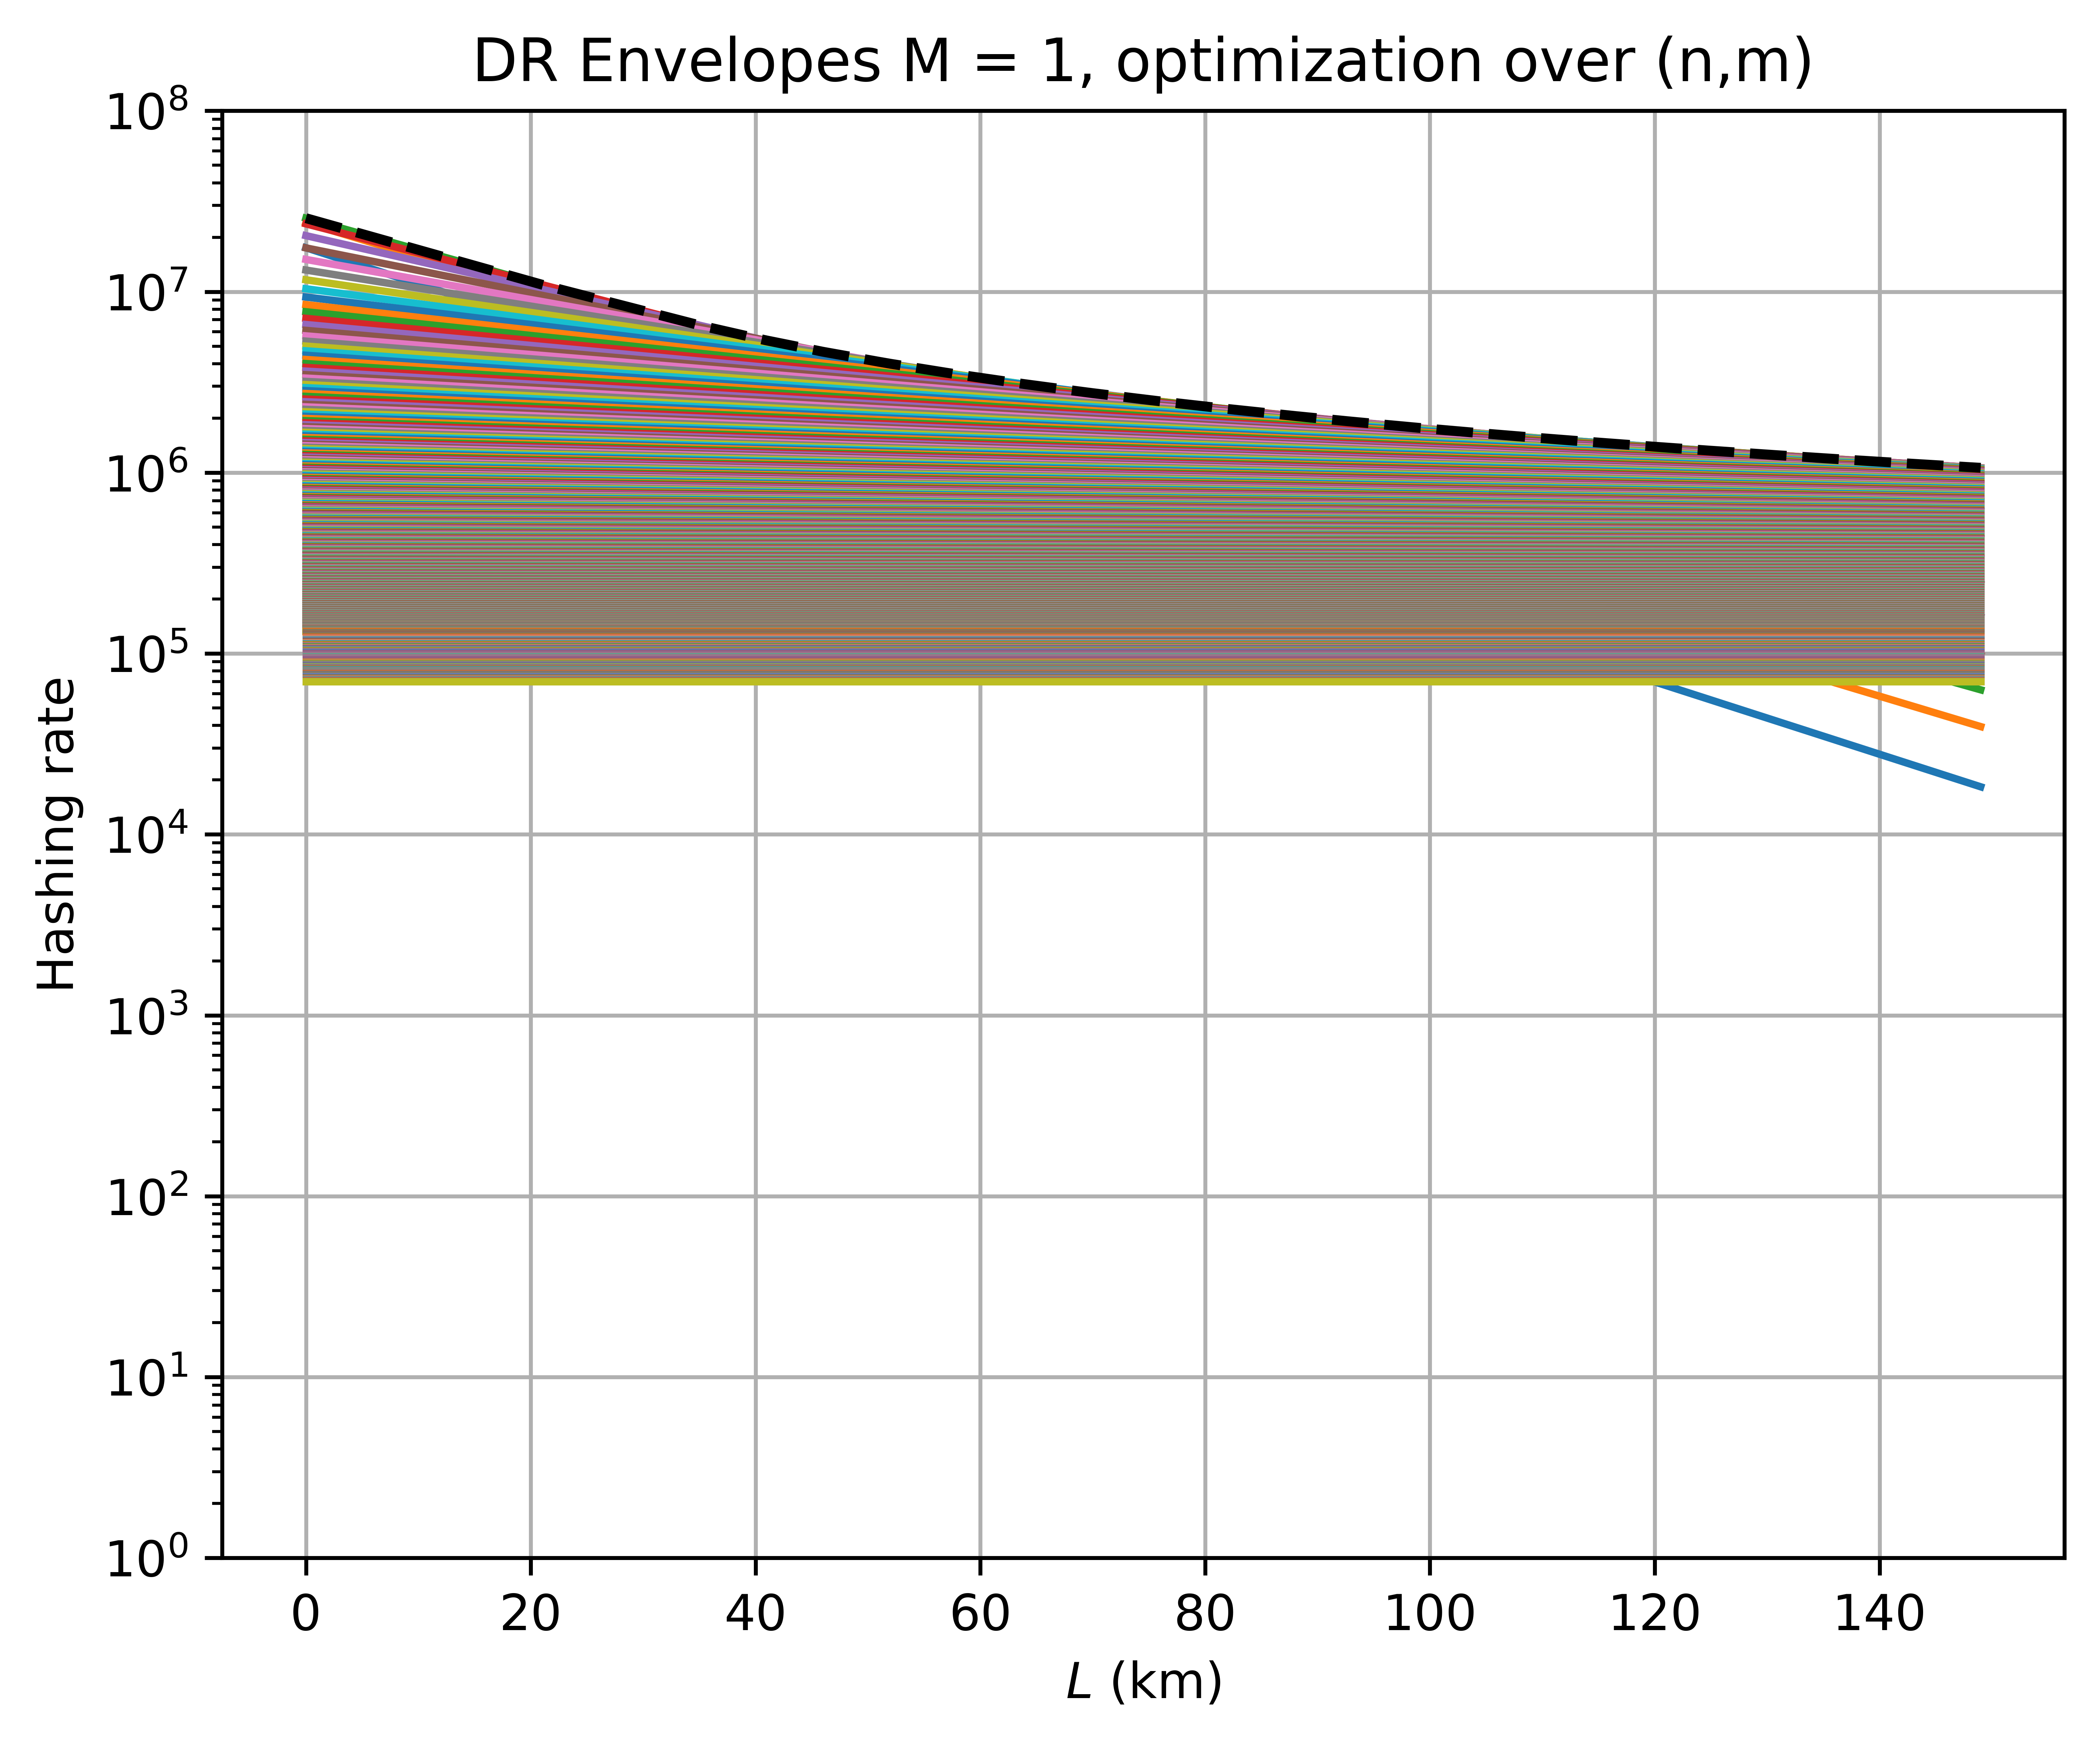

In [19]:
# dr_envs is already a list of arrays, one per m
env_matrix = np.array(dr_envs)  # shape: (len(m_values), len(Ls))
# fully maximized envelope over both n and m
fully_maximized_env = np.max(env_matrix, axis=0)


fig, ax = plt.subplots(figsize=(6,5), dpi=1000)

ax.set_yscale("log")
ax.set_title("DR Envelopes M = 1, optimization over (n,m)")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.set_ylim(bottom=1e0, top=1e8)
ax.grid(True)

color_cycle = plt.get_cmap("tab10")

# plot per-m envelopes
for i, env in enumerate(dr_envs):
    ax.plot(
        Ls,
        env,
        color=color_cycle(i % 10),
        linestyle="-",
        label=f"M = 1, m = {m_values[i]}"
    )

# plot fully maximized envelope
ax.plot(
    Ls,
    fully_maximized_env,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Maximized over n,m"
)

# ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_21297/1776416397.py:9: RuntimeWarning: divide by zero encountered in log2
  return -np.log2(1 - eta) * (M / tau)


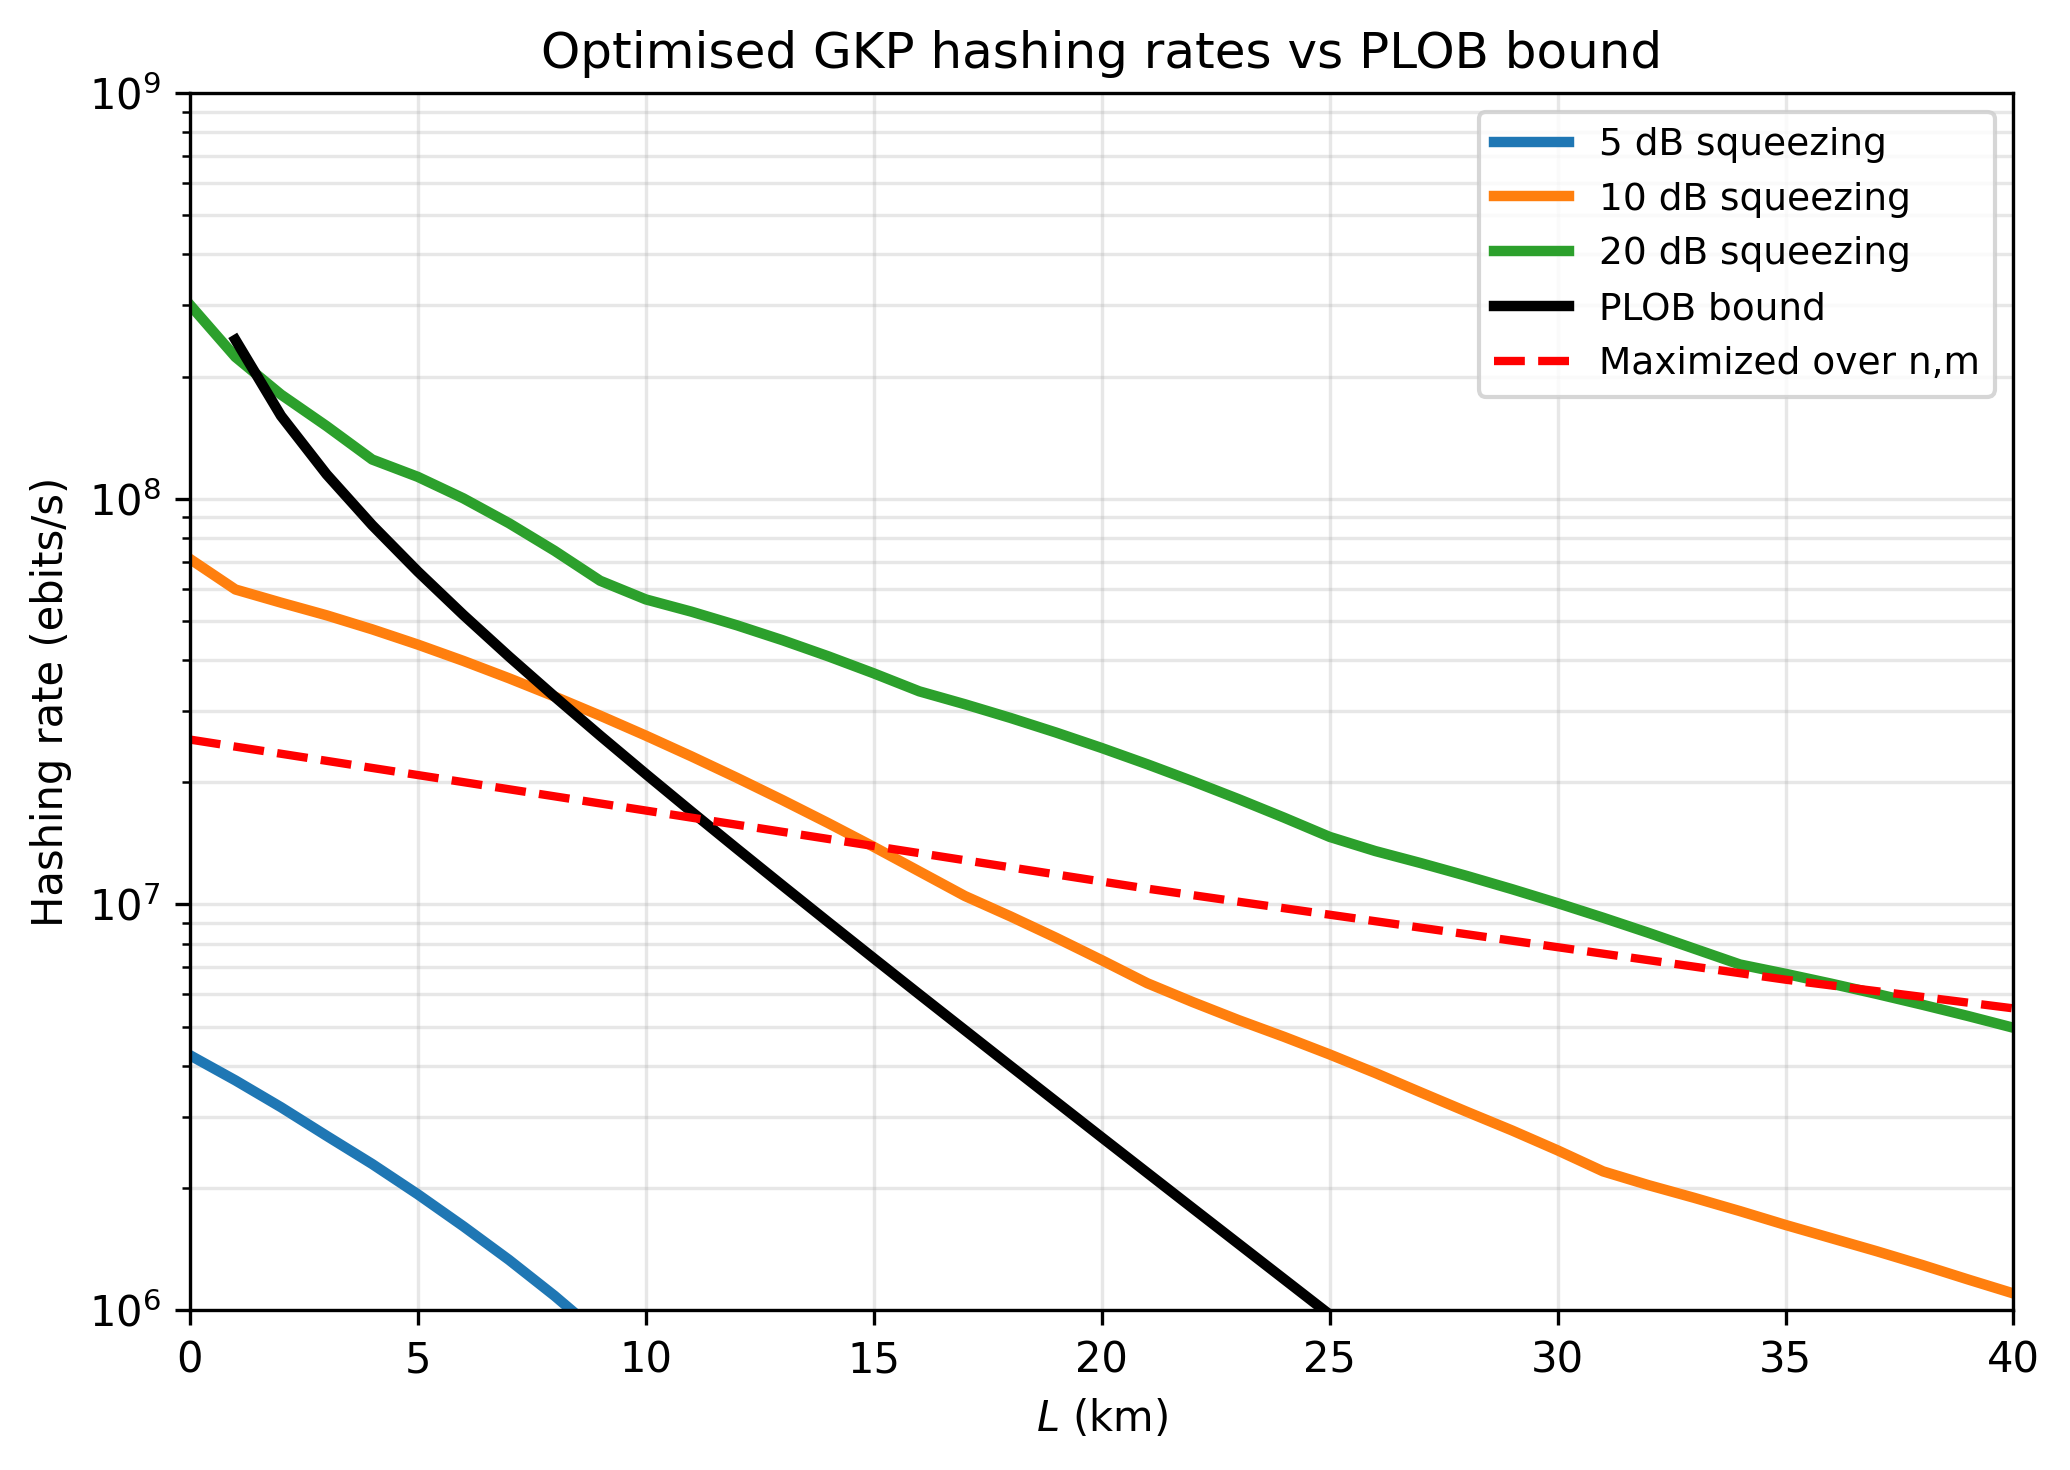

In [21]:
# ============================================================
# L grid
# ============================================================

Ls = np.arange(0, 150, 1.0)

PLOB_bound_tab = PLOB_bound(
    Ls,
    alpha_dB_per_km=0.2,
    M=M,
    tau=tau
)


# ============================================================
# Plot maximised GKP envelopes + PLOB
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5),
    dpi=300
)


# ------------------------------------------------------------
# Plot globally maximised GKP envelope for each squeezing
# ------------------------------------------------------------

for squeezing_dB in [5, 10, 20]:

    ax.plot(
        Ls,
        global_gkp_envelopes[squeezing_dB],
        linewidth=2.5,
        label=f"{squeezing_dB} dB squeezing"
    )


# ------------------------------------------------------------
# Plot PLOB bound
# ------------------------------------------------------------

ax.plot(
    Ls,
    PLOB_bound_tab,
    color="black",
    linestyle="-",
    linewidth=2.5,
    label="PLOB bound"
)

# plot fully maximized envelope
ax.plot(
    Ls,
    fully_maximized_env,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Maximized over n,m"
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_yscale("log")

ax.set_ylim(
    bottom=1e6,
    top=1e9
)

ax.set_xlim(
    left=0,
    right=40
)

ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate (ebits/s)")

ax.set_title(
    "Optimised GKP hashing rates vs PLOB bound"
)

ax.grid(
    True,
    which="both",
    alpha=0.3
)

ax.legend(
    fontsize=9
)

plt.tight_layout()

plt.show()
plt.close(fig)

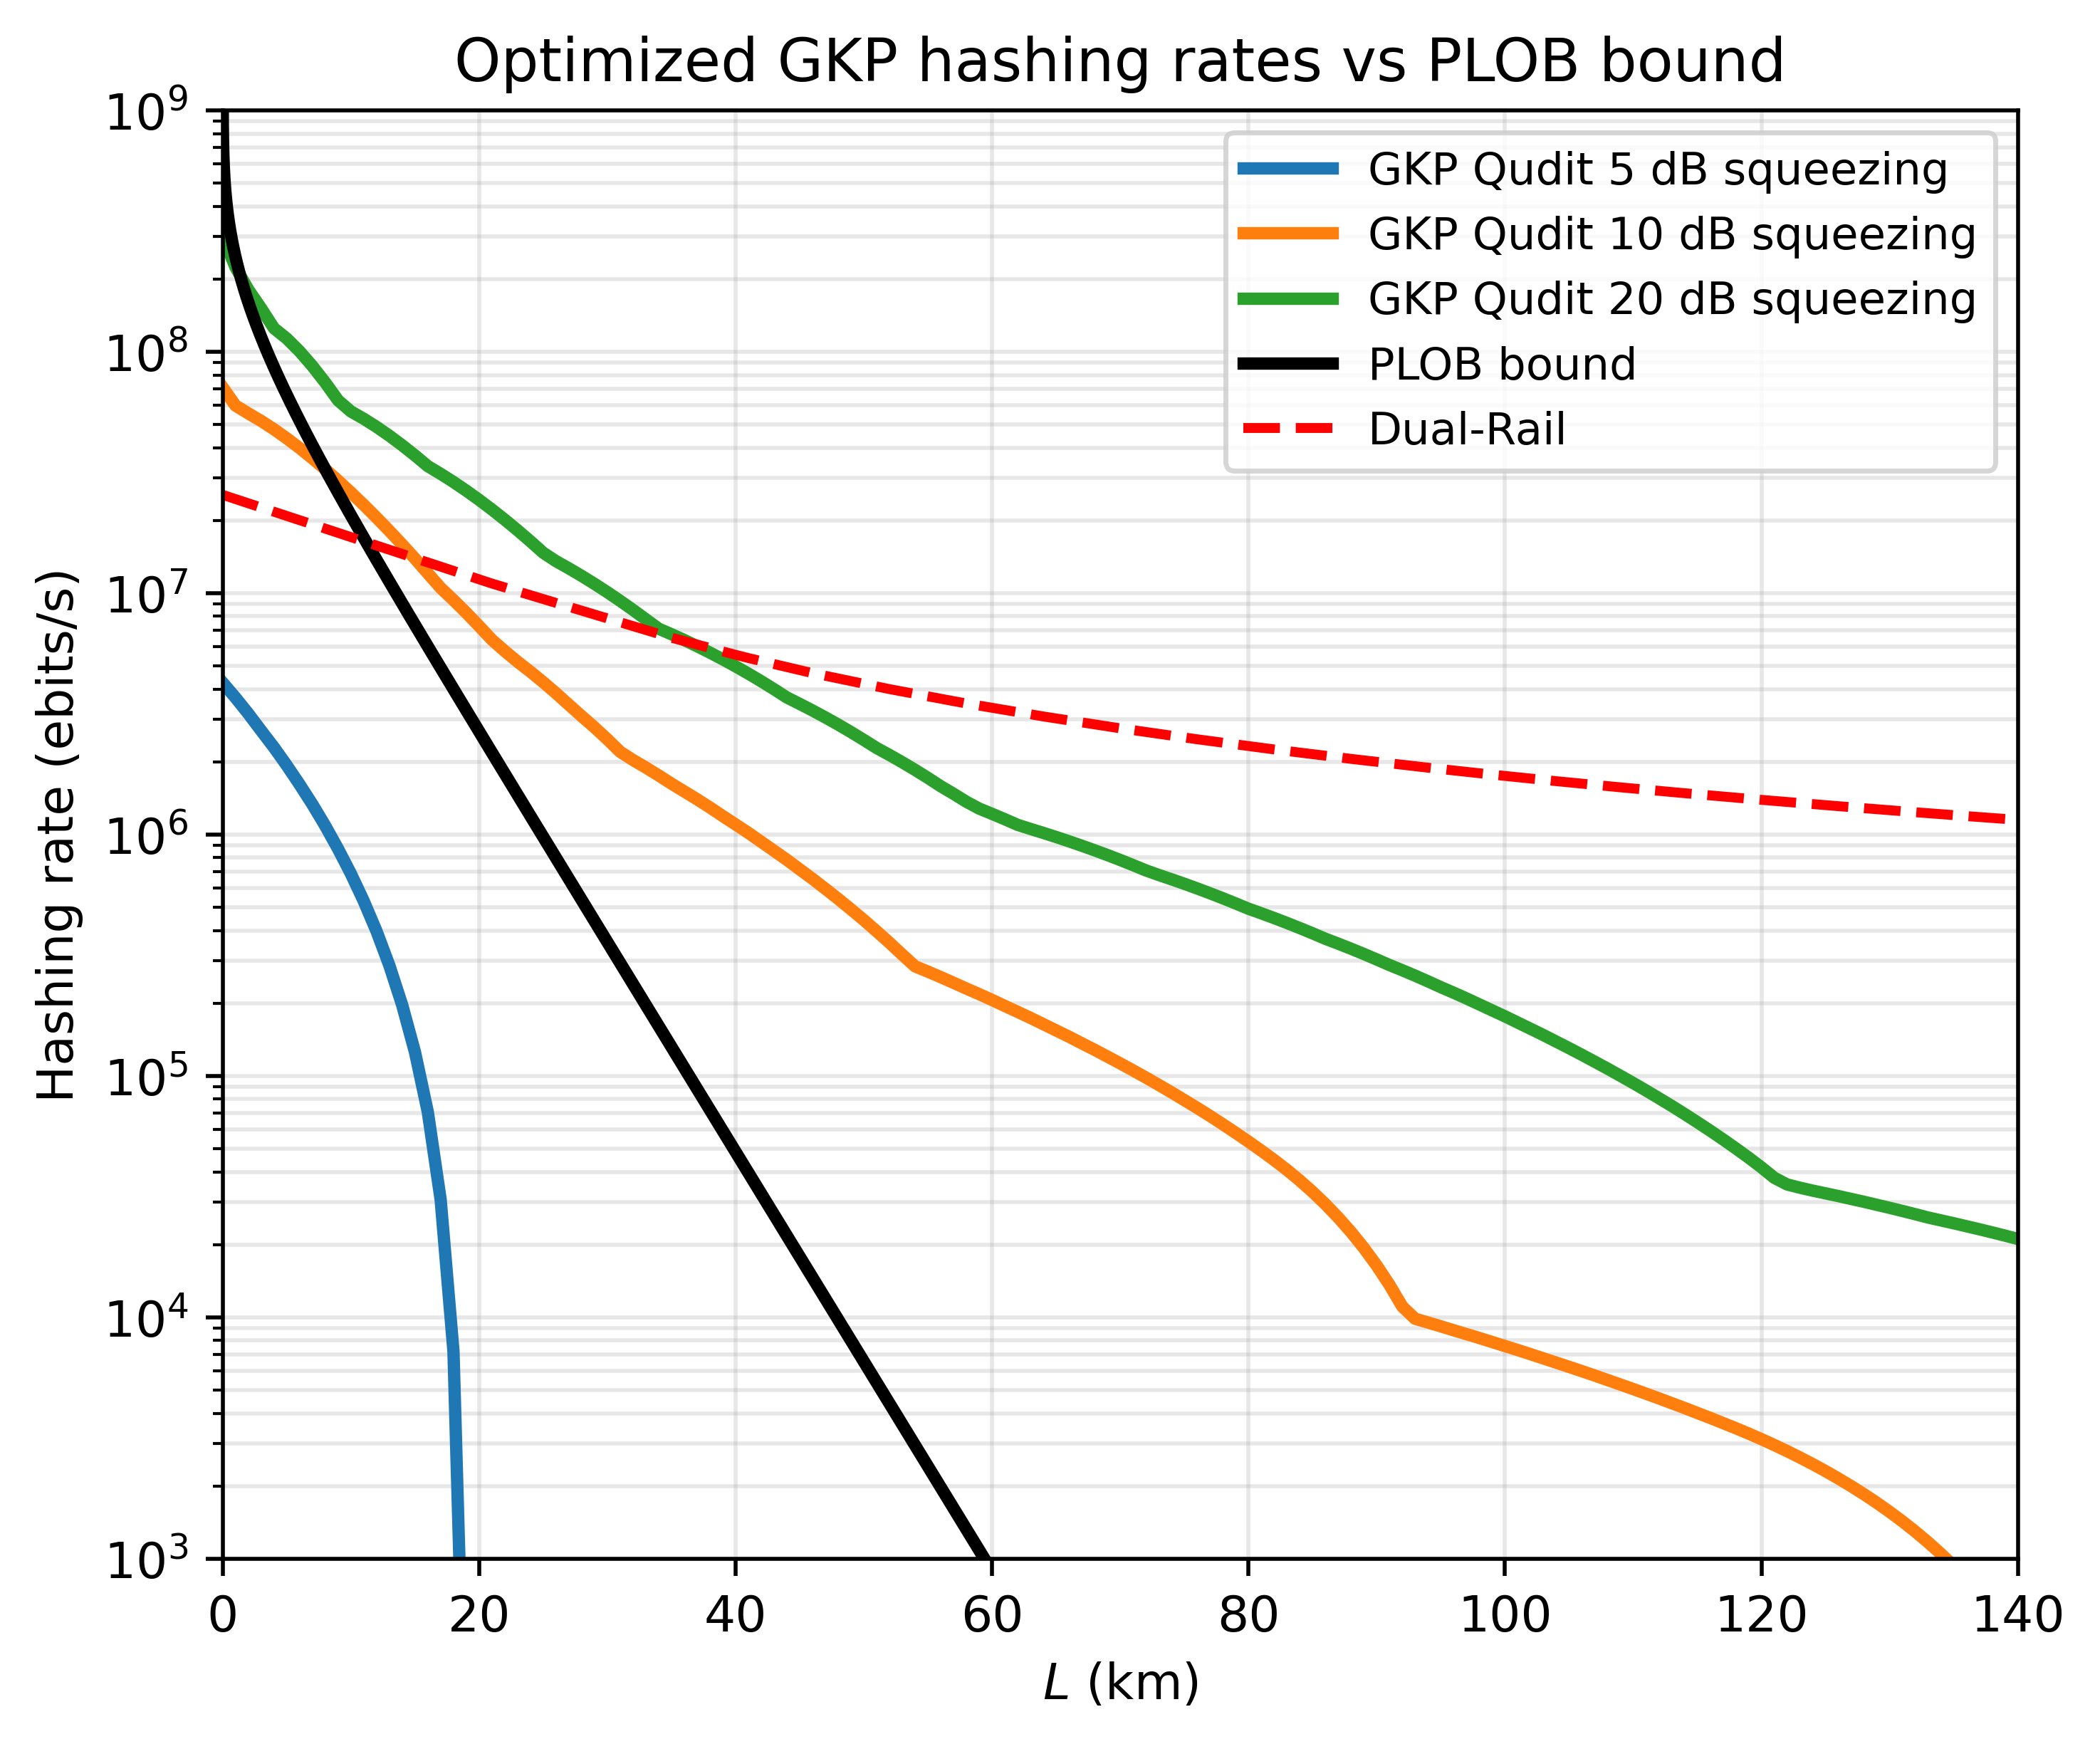

In [33]:
# ============================================================
# Distance grids
# ============================================================

# Existing grid for GKP and dual-rail data
Ls = np.arange(0, 150, 1.0)

# Fine grid for PLOB to resolve the L -> 0 behaviour
Ls_plob = np.arange(0.001, 150.001, 0.001)

PLOB_bound_tab = PLOB_bound(
    Ls_plob,
    alpha_dB_per_km=0.2,
    M=M,
    tau=tau
)


# ============================================================
# Plot maximised GKP envelopes + PLOB
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 5),
    dpi=500
)


# ------------------------------------------------------------
# Plot globally maximised GKP envelope for each squeezing
# ------------------------------------------------------------

for squeezing_dB in [5, 10, 20]:

    ax.plot(
        Ls,
        global_gkp_envelopes[squeezing_dB],
        linewidth=2.5,
        label=f"GKP Qudit {squeezing_dB} dB squeezing"
    )


# ------------------------------------------------------------
# Plot PLOB bound
# ------------------------------------------------------------

ax.plot(
    Ls_plob,
    PLOB_bound_tab,
    color="black",
    linestyle="-",
    linewidth=2.5,
    label="PLOB bound"
)


# ------------------------------------------------------------
# Plot fully maximised envelope
# ------------------------------------------------------------

ax.plot(
    Ls,
    fully_maximized_env,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Dual-Rail"
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_yscale("log")

ax.set_ylim(
    bottom=1e3,
    top=1e9
)

ax.set_xlim(
    left=0,
    right=140
)

ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate (ebits/s)")

ax.set_title(
    "Optimized GKP hashing rates vs PLOB bound"
)

ax.grid(
    True,
    which="both",
    alpha=0.3
)

ax.legend(
    fontsize=9
)

plt.tight_layout()

plt.show()

plt.close(fig)